In [9]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 15.7 MB/s eta 0:00:07
   --- ------------------------------------ 7.9/101.7 MB 26.8 MB/s eta 0:00:04
   ---------- ----------------------------- 25.7/101.7 MB 50.4 MB/s eta 0:00:02
   ------------------ --------------------- 47.2/101.7 MB 65.9 MB/s eta 0:00:01
   ---------------------- ----------------- 57.9/101.7 MB 61.6 MB/s eta 0:00:01
   ------------------------- -------------- 65.0/101.7 MB 57.2 MB/s eta 0:00:01
   ---------------------------- ----------- 72.9/101.7 MB 54.2 MB/s eta 0:00:01
   -------------------------------- ------- 81.5/101.7 MB 52.2 MB/s eta 0:00:01
   ----------------------------------- ---- 90.4/101.7 MB 51.0 MB/s eta 0:00:01
   -------------------------------------- - 99.1/101.7 MB 49.7 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 49.6 MB/s eta 0:00:01
   ---------------------------------------- 101.7/1

In [30]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.expand_frame_repr', False)

# Opciono: da ti ne skraćuje kolone u sredini (one tri tačkice ...)
pd.set_option('display.max_columns', None)

# Opciono: da povećaš širinu svake kolone ako je tekst dugačak
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv("member_stats_training.csv")

In [3]:
df.head()

,clan_id,user_id,days_active_last_28_days,days_active_last_7_days,days_since_last_active,registration_country,registration_platform_specific,cohort_day,training_count_last_28_days,is_payer_lifetime,dynamic_payment_segment,clan_multiplier,avg_stars_top_11_players,avg_stars_top_3_players,avg_training_bonus
0,clan_1,user_1,28,7,0,Israel,Android Phone,1721,159,True,4) Whale,3,8.219321,9.440622,15.5
1,clan_2,user_2,27,7,0,Malaysia,Android Phone,2923,214,True,4) Whale,2,8.931697,9.882221,15.5
2,clan_3,user_3,28,7,0,Poland,Android Phone,219,2930,True,4) Whale,3,8.545721,8.980044,17.0
3,clan_4,user_4,28,7,0,Germany,iOS Phone,47,57,True,4) Whale,3,7.895794,8.737822,15.5
4,clan_5,user_5,28,7,0,France,Android Phone,1181,4179,True,4) Whale,4,8.170182,9.144755,16.5


In [7]:
df.describe()

,days_active_last_28_days,days_active_last_7_days,days_since_last_active,cohort_day,training_count_last_28_days,clan_multiplier,avg_stars_top_11_players,avg_stars_top_3_players,avg_training_bonus
count,291456.000000,291456.000000,291456.000000,291456.000000,291456.000000,291456.000000,291456.000000,291456.000000,291456.000000
mean,21.992198,5.490369,5.425666,1240.835913,132.004642,2.677557,5.764373,6.634312,8.208093
std,9.671382,2.565398,15.811683,1409.331688,479.544244,0.587085,1.351140,1.510741,5.154863
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.486751,2.856445,0.000000
25%,20.000000,5.000000,0.000000,190.000000,19.000000,2.000000,4.882909,5.615112,3.000000
50%,28.000000,7.000000,0.000000,660.000000,50.000000,3.000000,5.713539,6.549733,10.000000
75%,28.000000,7.000000,0.000000,1759.000000,109.000000,3.000000,6.628124,7.579955,12.500000
max,28.000000,7.000000,118.000000,5690.000000,102501.000000,4.000000,17.176715,17.467778,30.000000


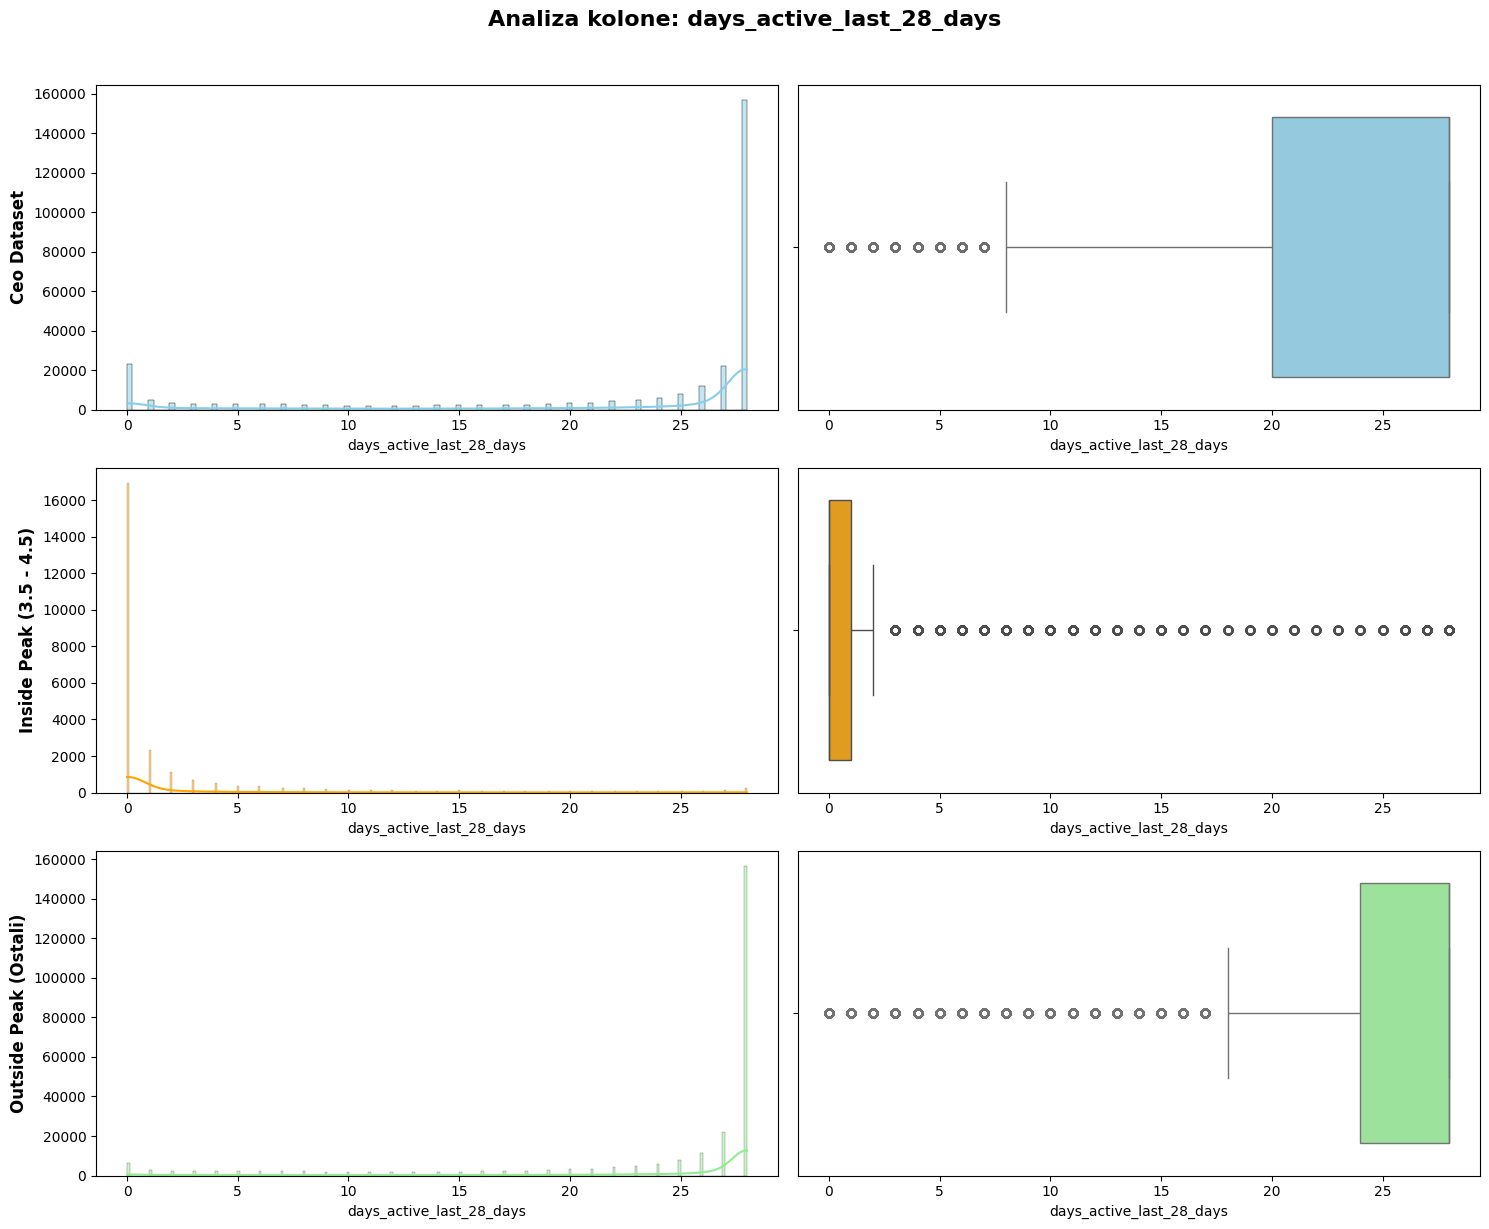

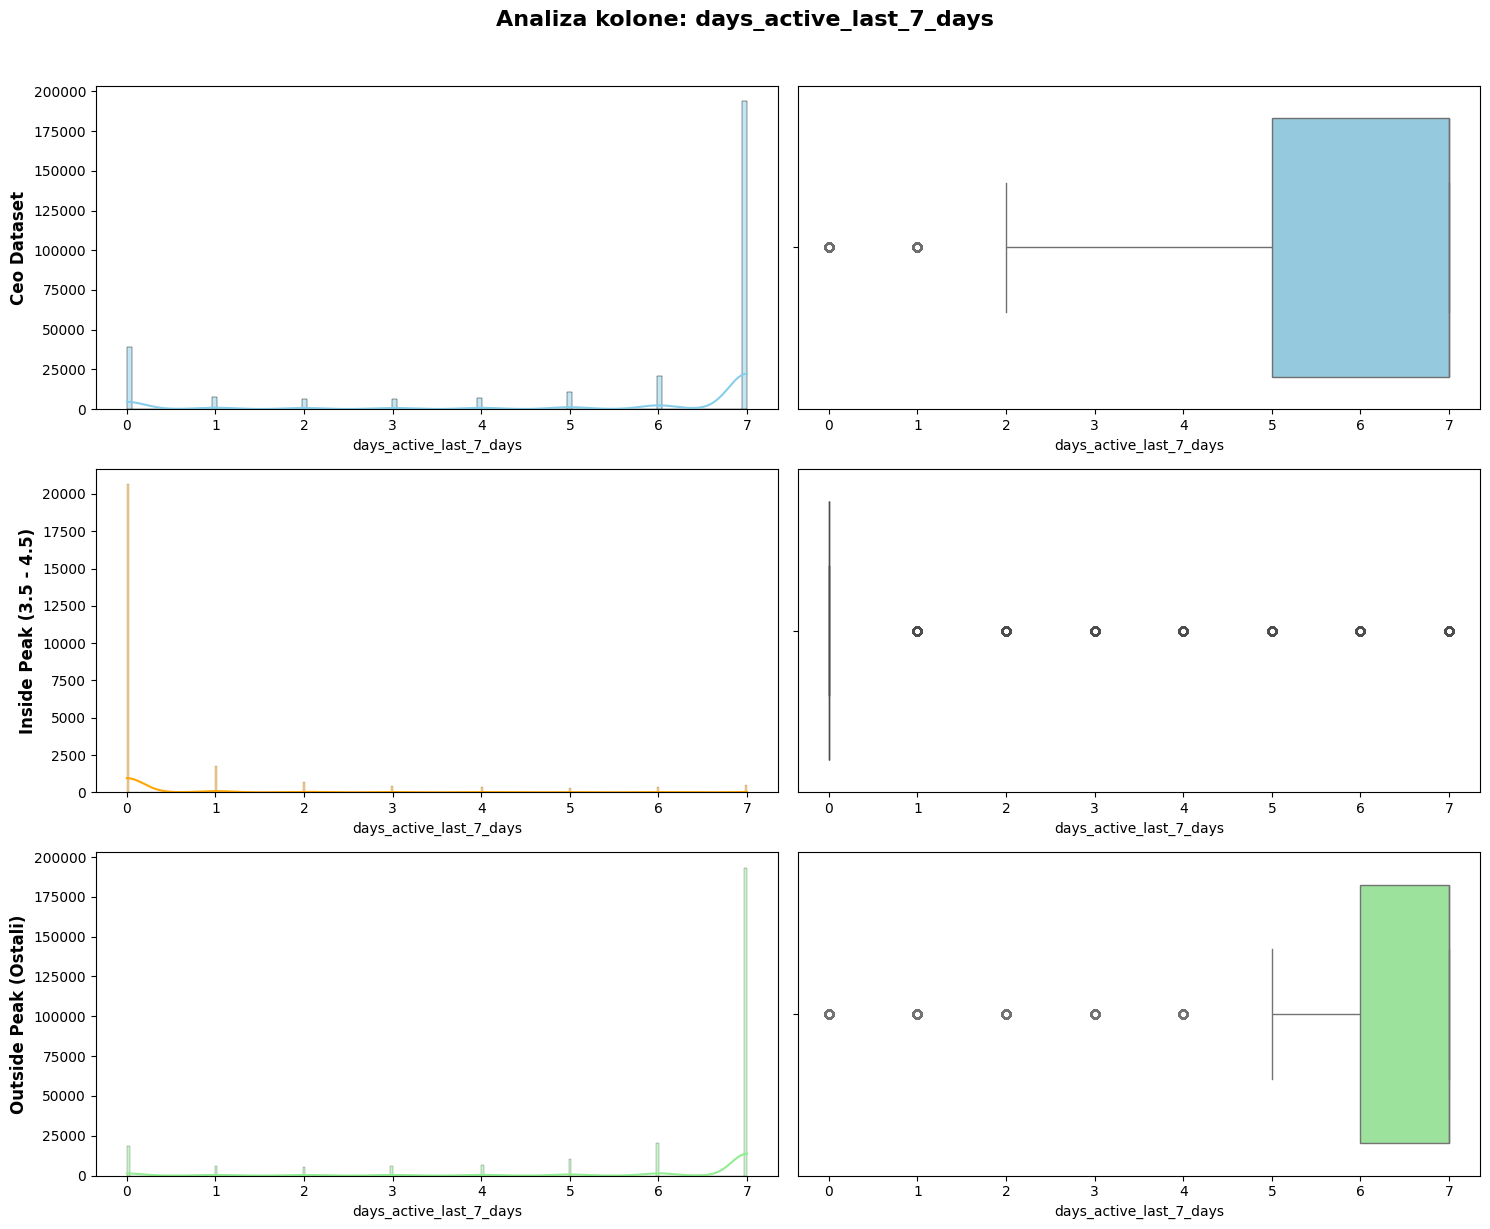

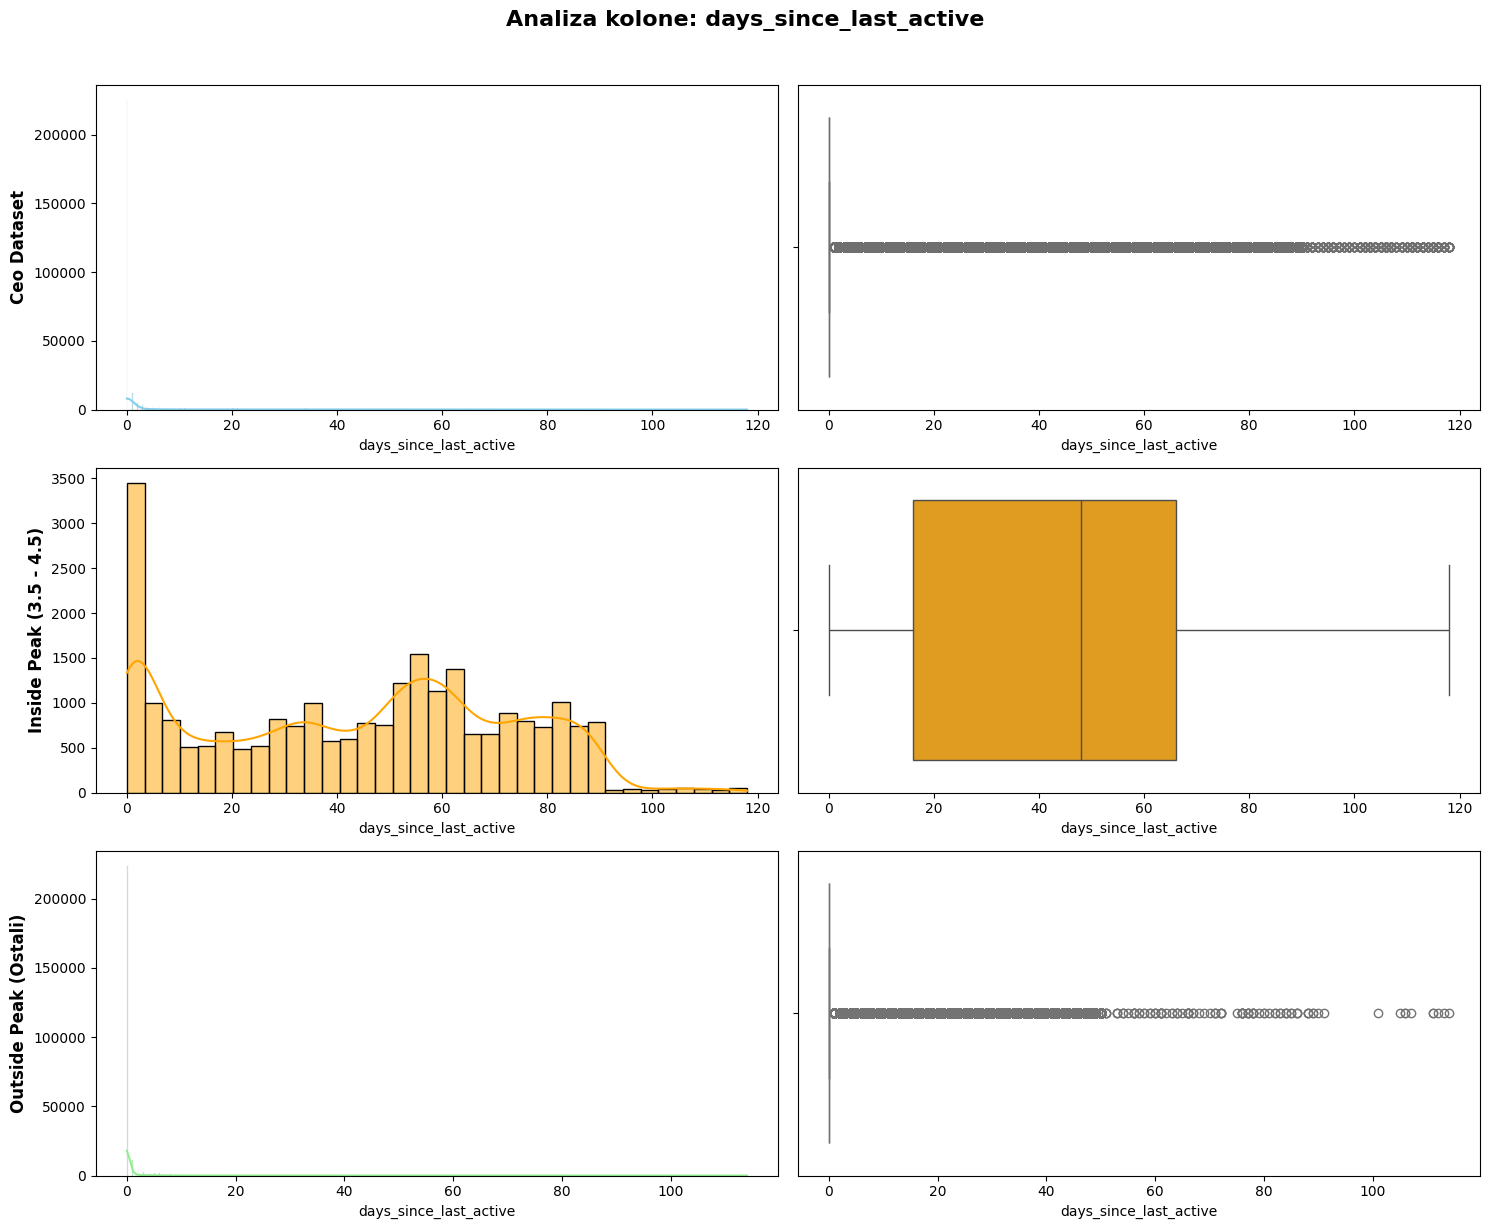

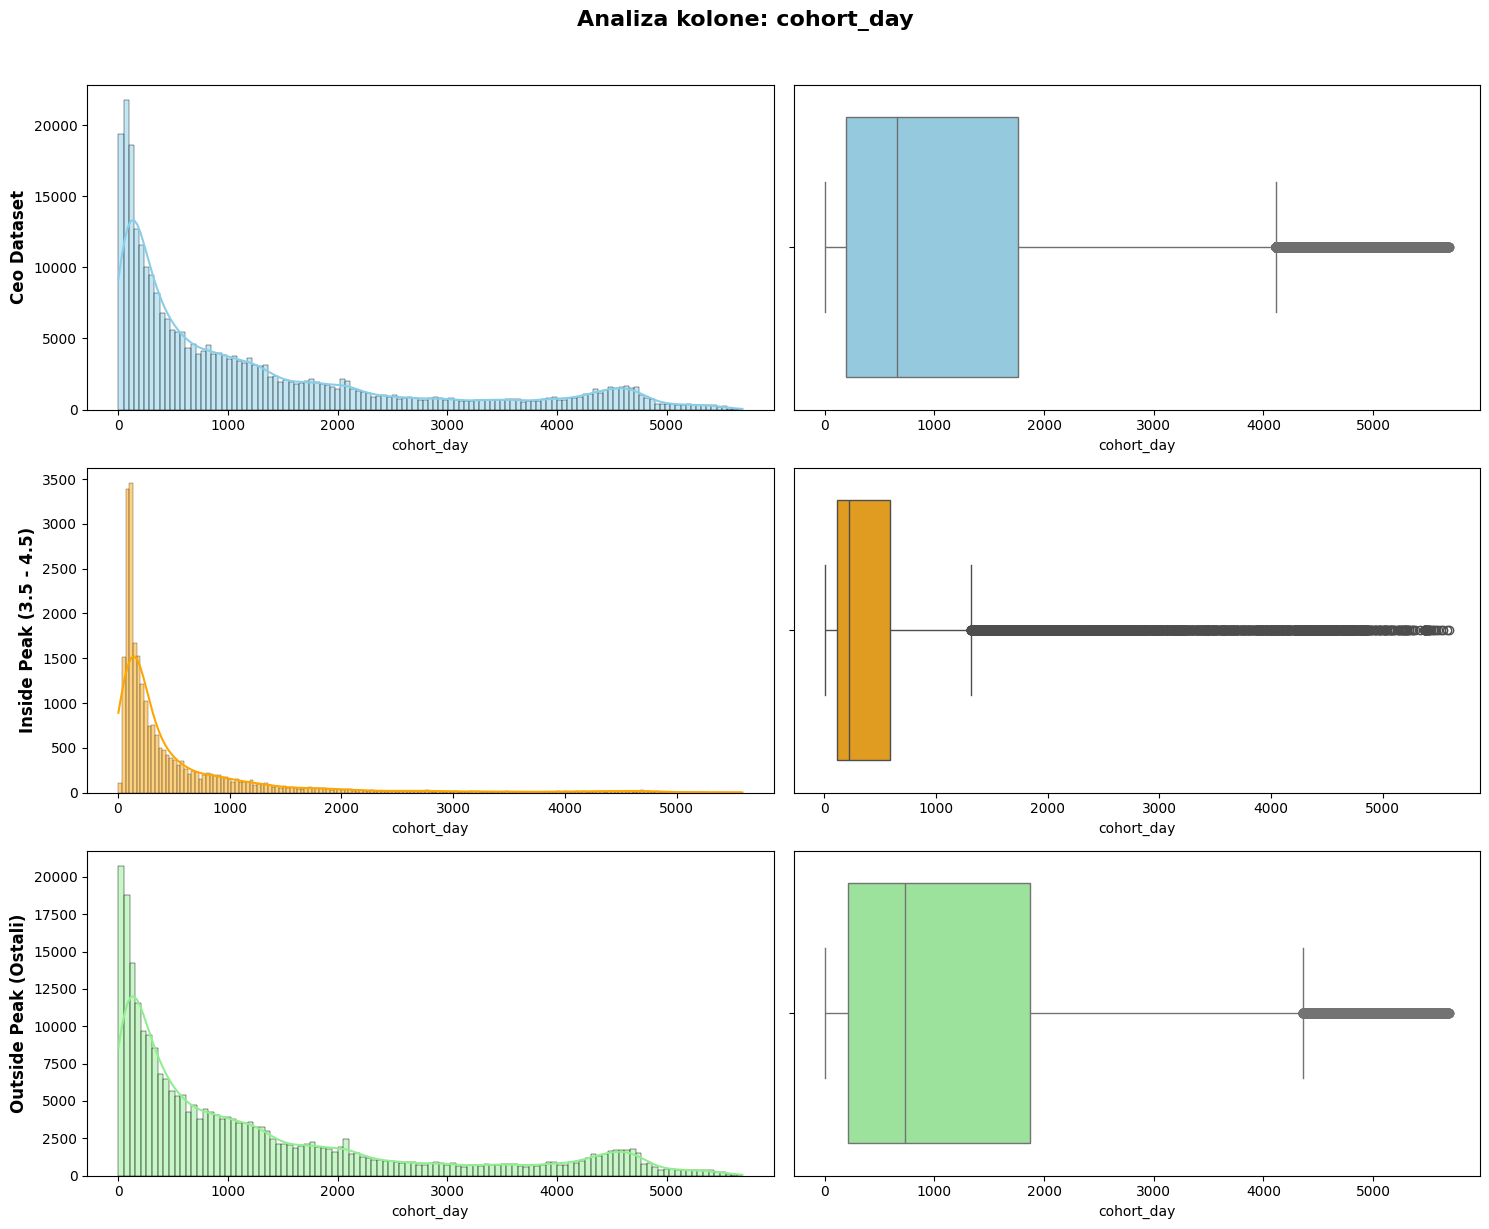

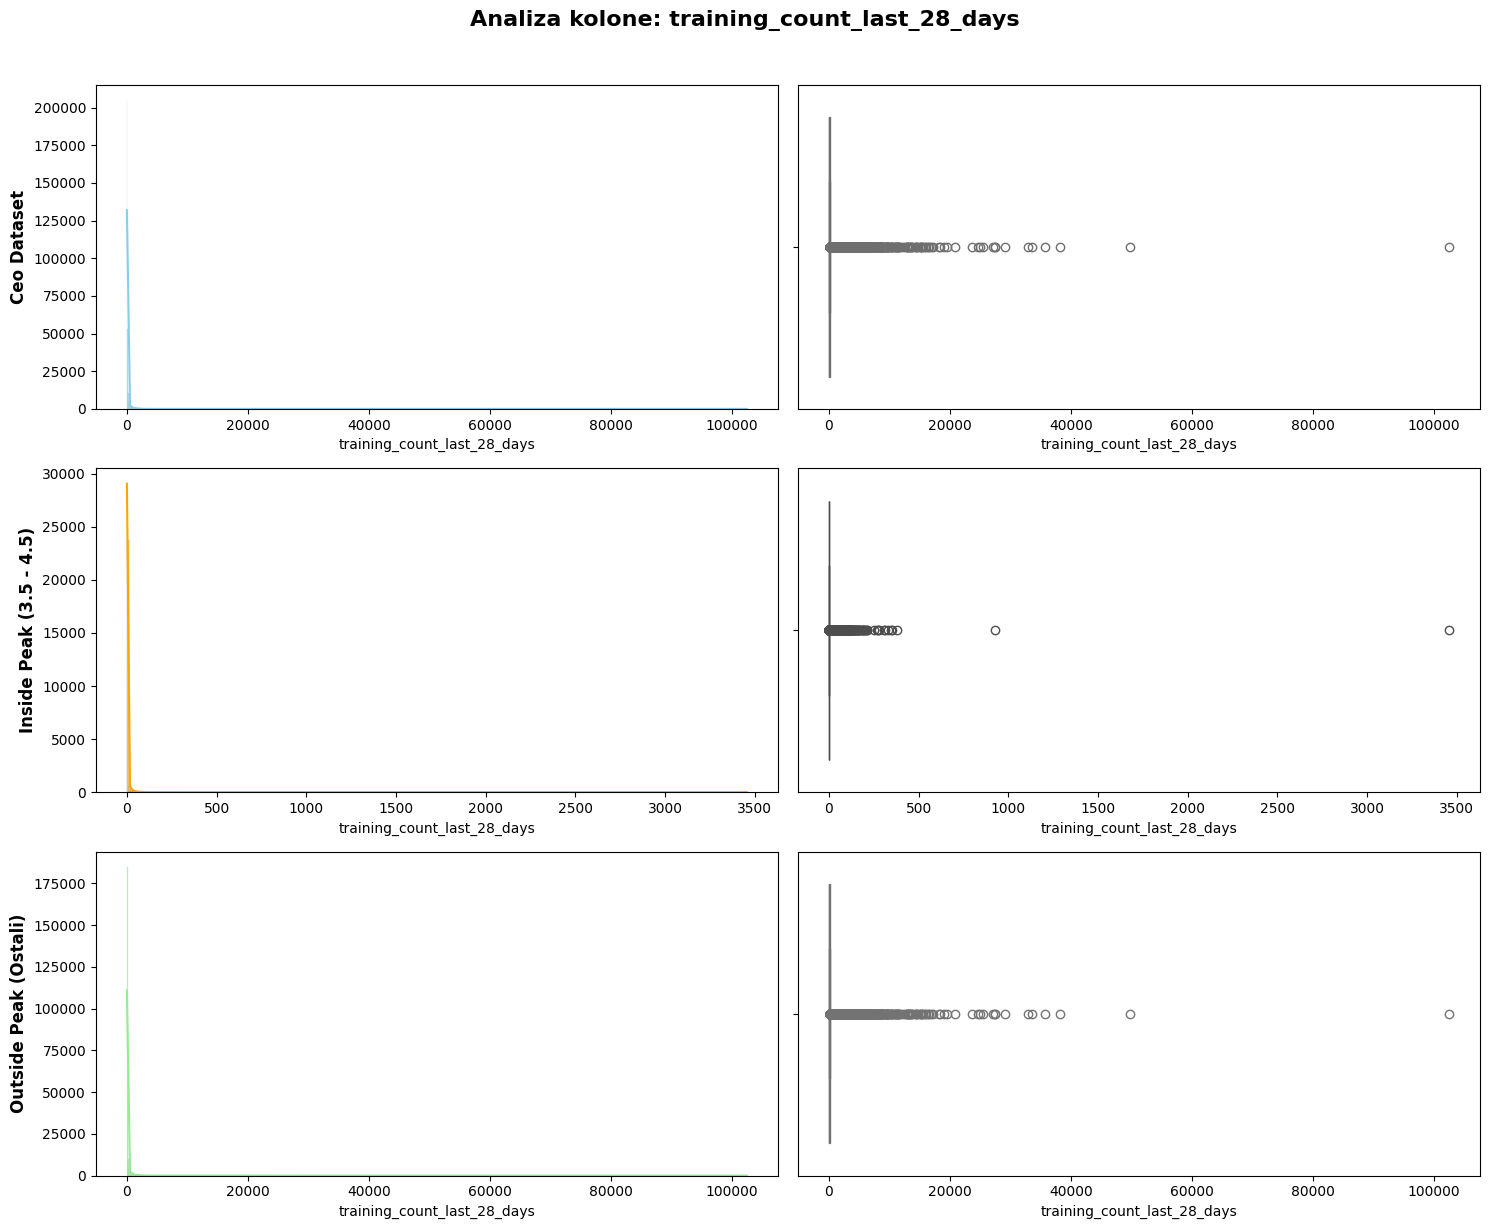

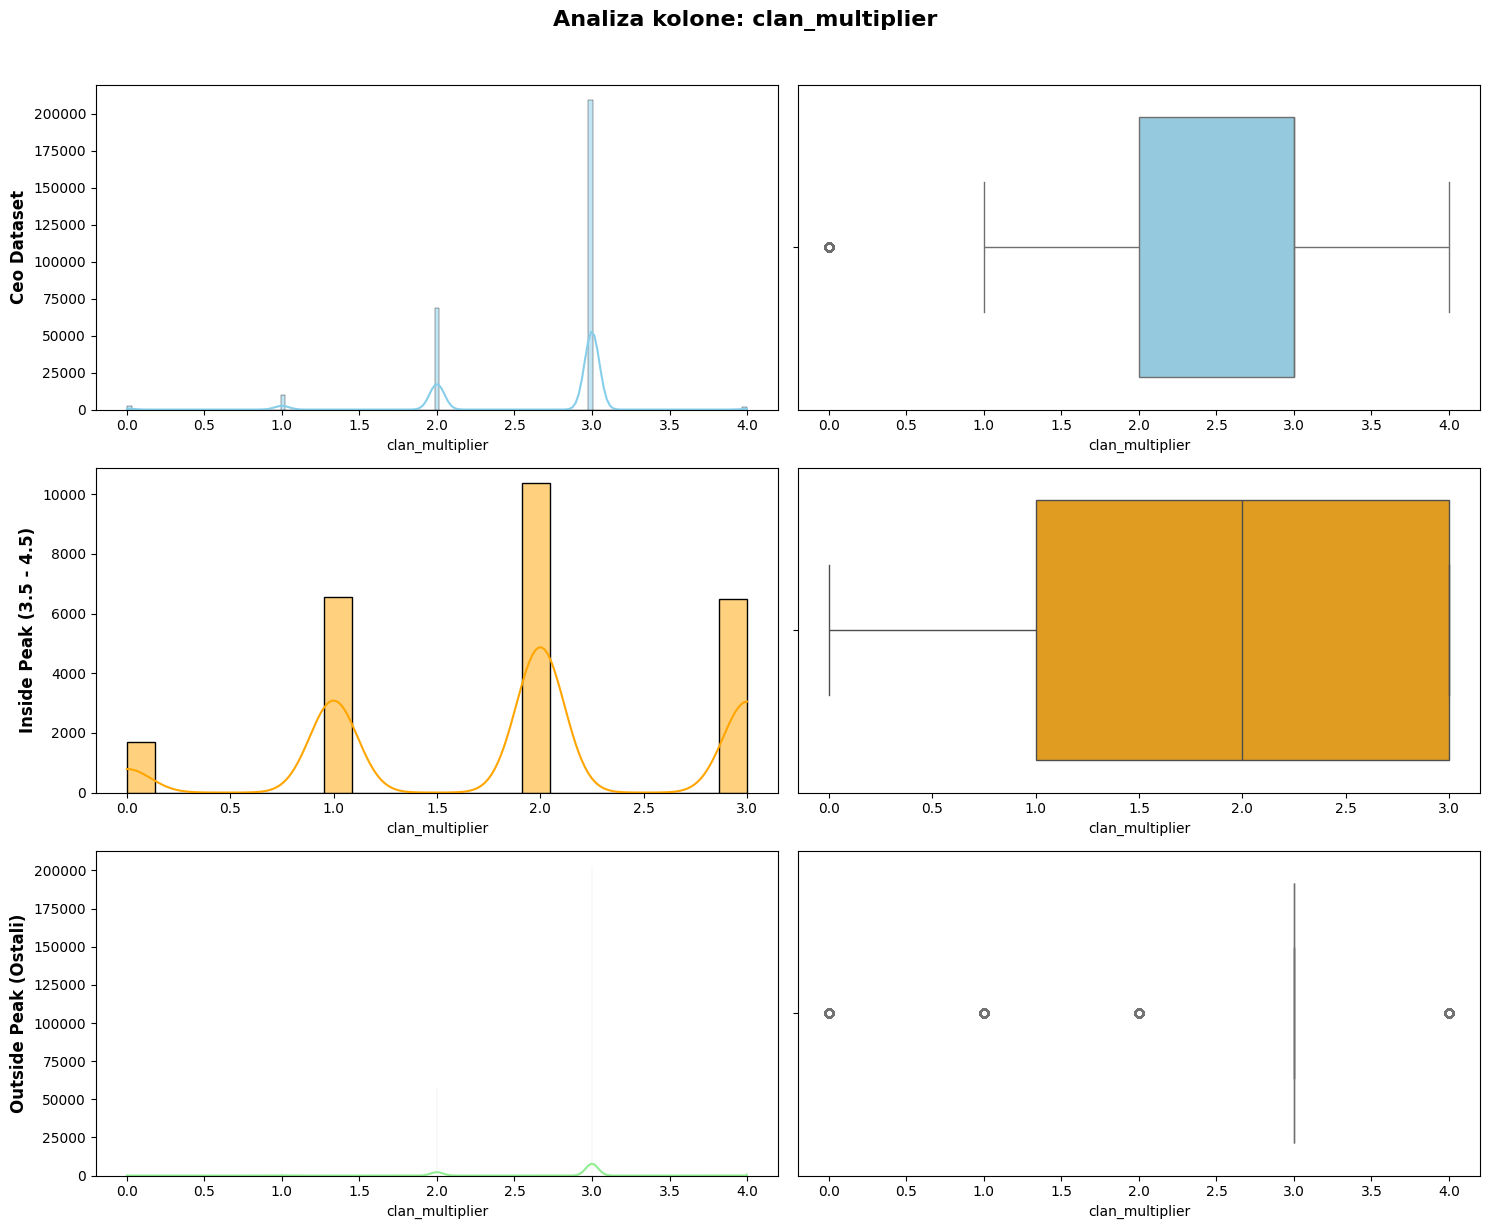

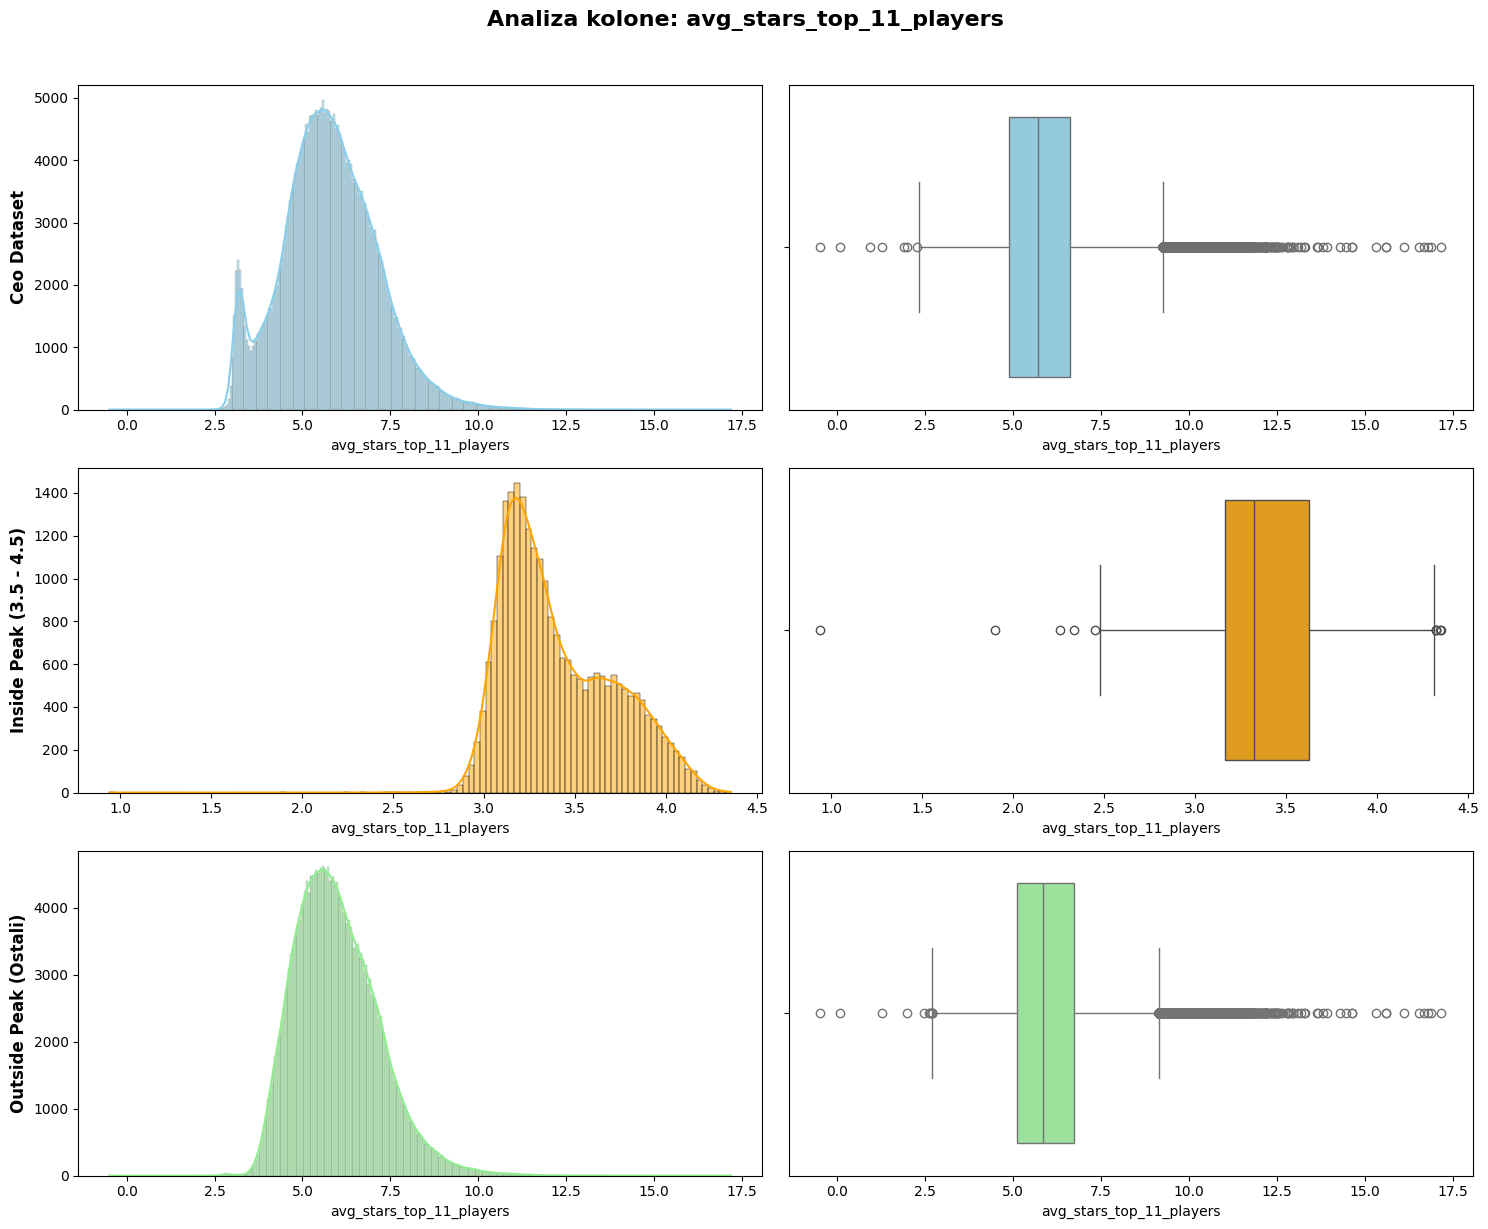

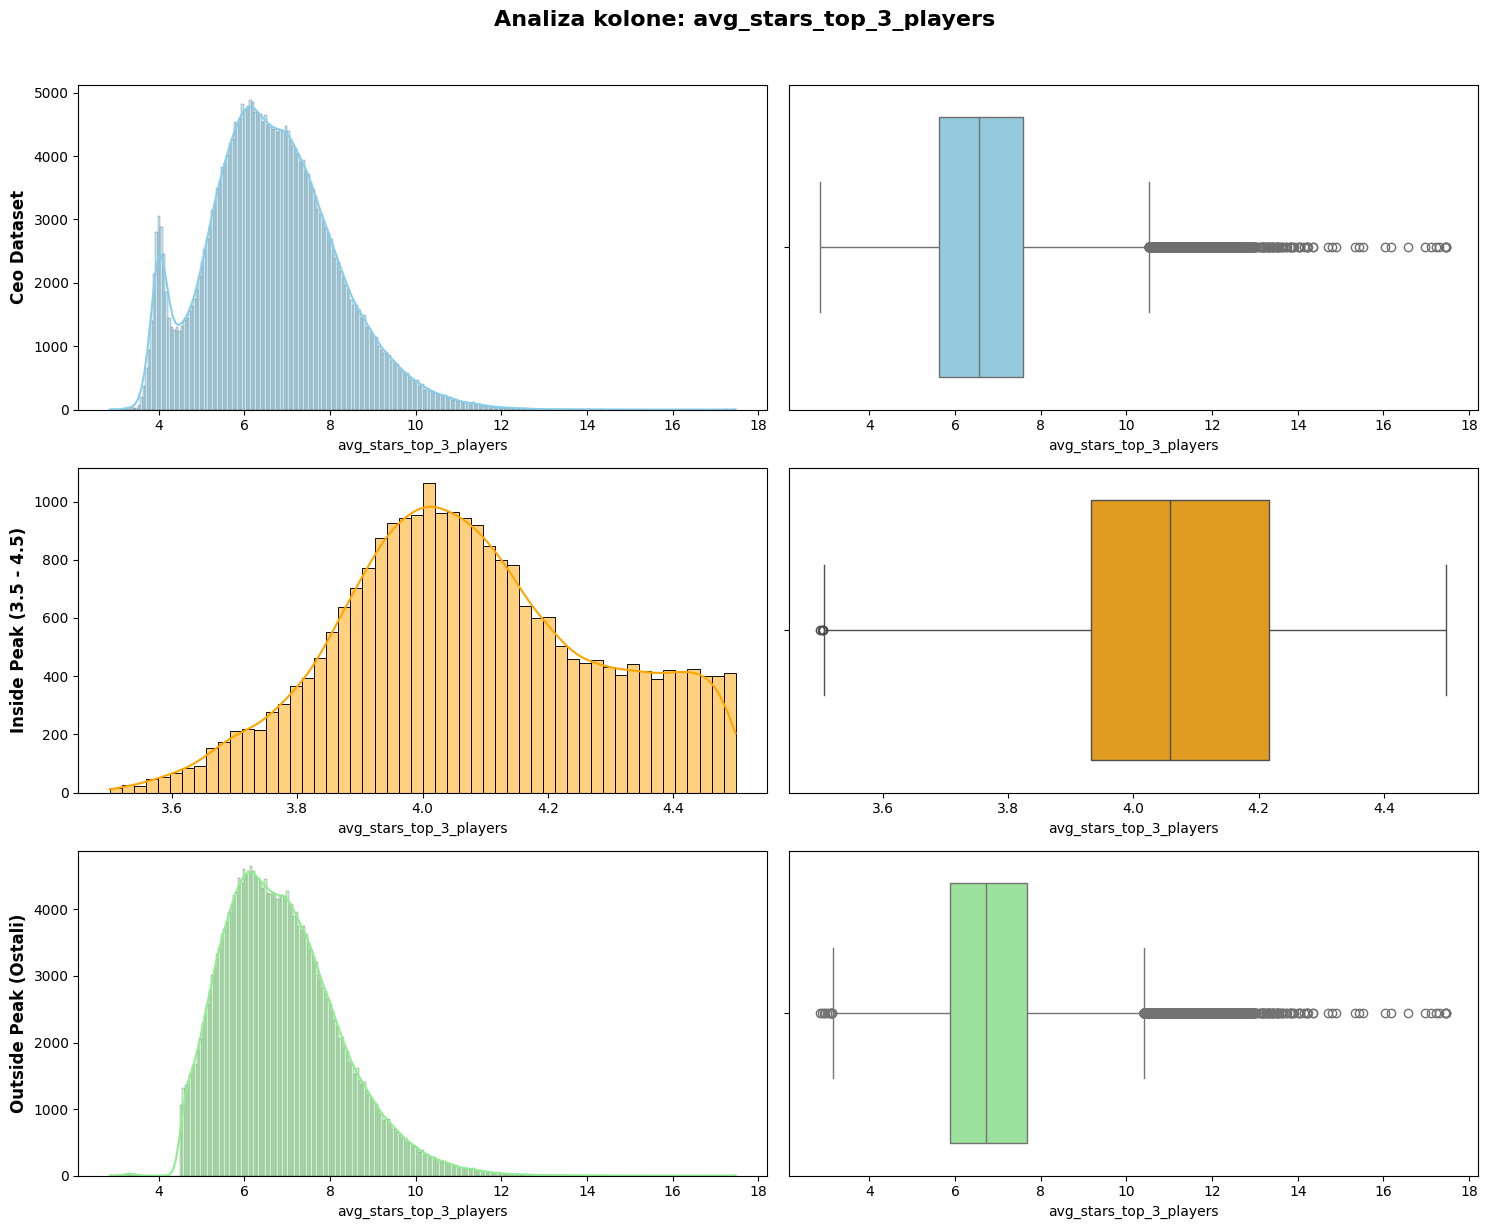

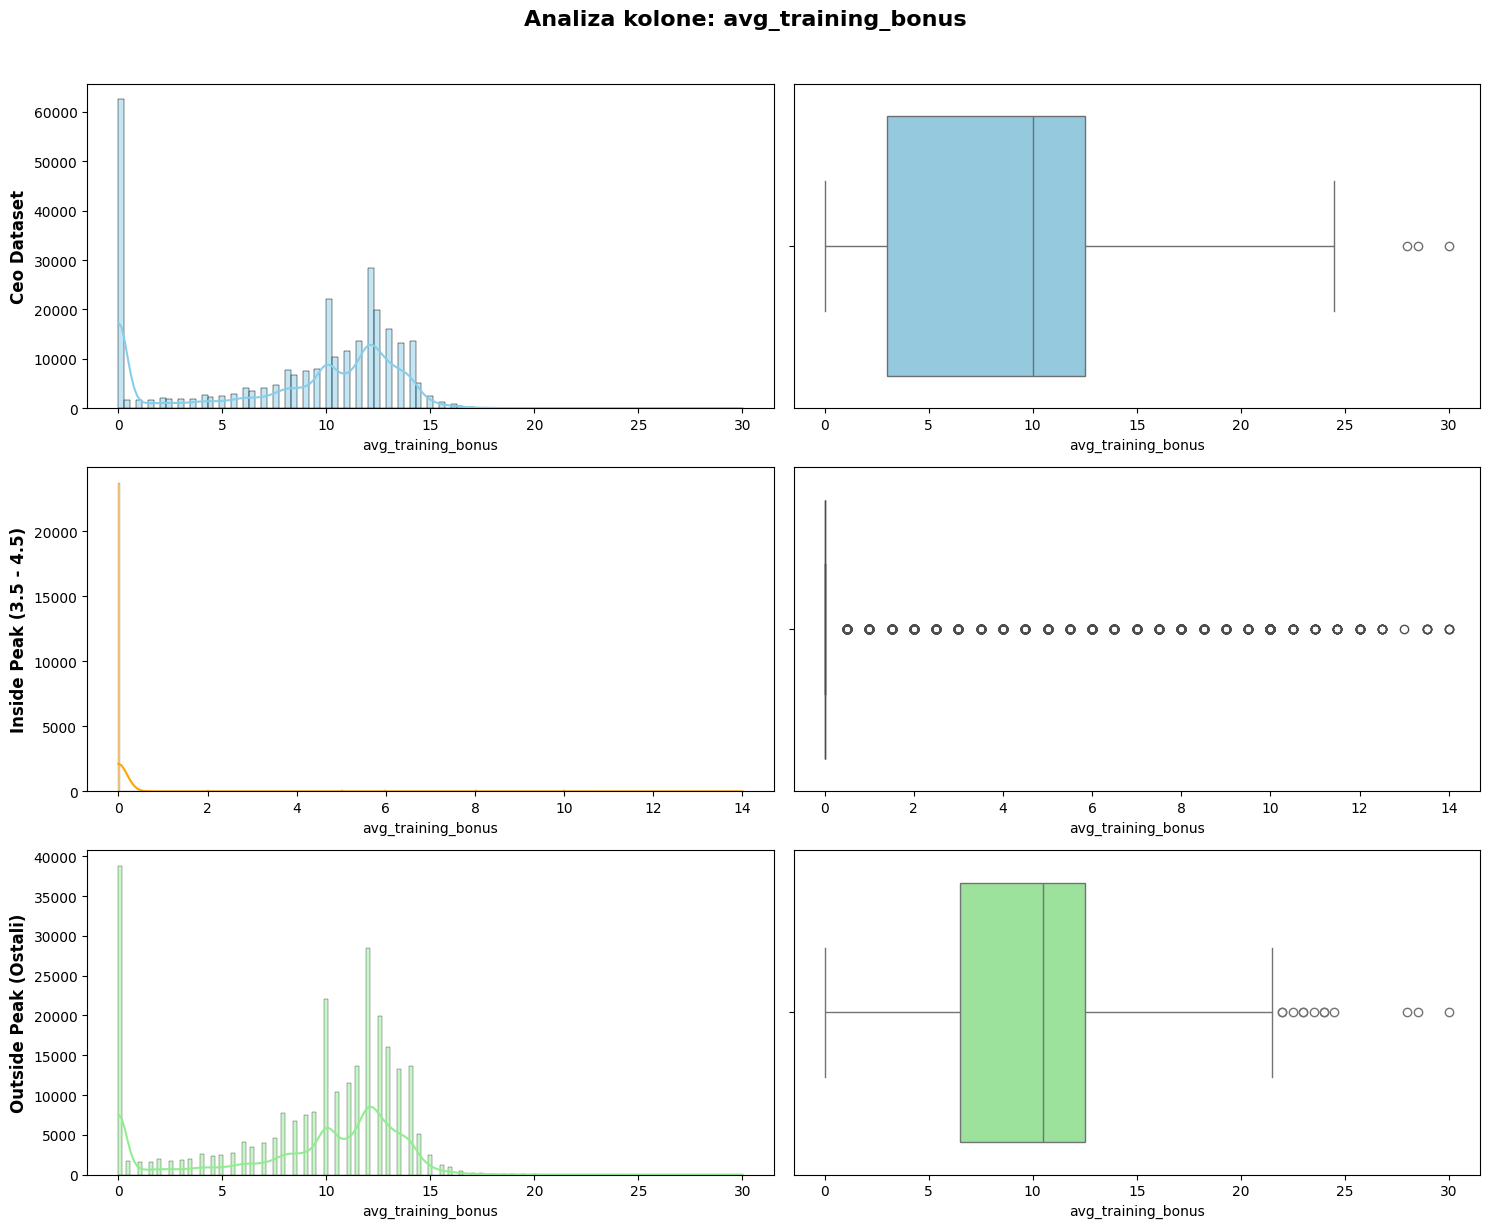

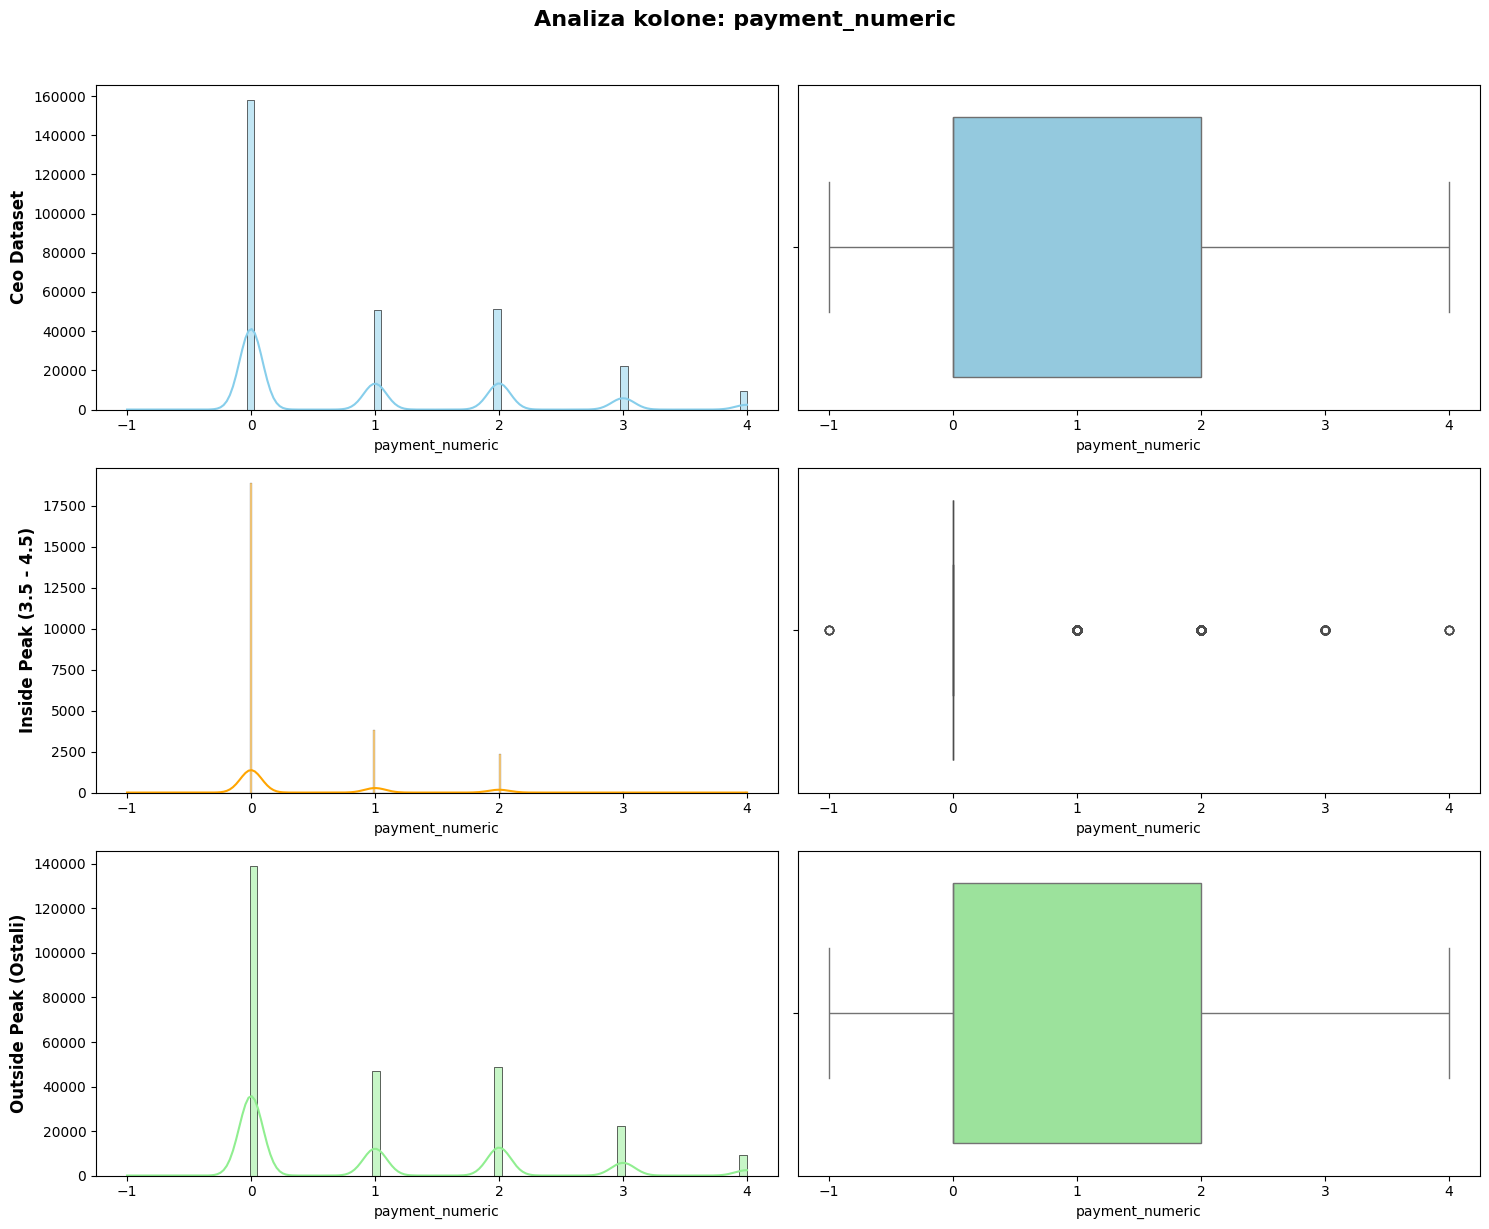

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pripremamo tri grupe podataka
df_all = df
df_inside = df[df['avg_stars_top_3_players'].between(3.5, 4.5)]
df_outside = df[~df['avg_stars_top_3_players'].between(3.5, 4.5)]

groups = [
    (df_all, "Ceo Dataset", "skyblue"),
    (df_inside, "Inside Peak (3.5 - 4.5)", "orange"),
    (df_outside, "Outside Peak (Ostali)", "lightgreen")
]

# Uzimamo numeričke kolone
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    # Kreiramo grid: 3 reda (za svaku grupu) i 2 kolone (hist i box)
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle(f'Analiza kolone: {col}', fontsize=16, fontweight='bold', y=1.02)

    for i, (data, label, color) in enumerate(groups):
        # Histogram (leva kolona)
        sns.histplot(data[col], kde=True, ax=axes[i, 0], color=color)
        axes[i, 0].set_ylabel(label, fontsize=12, fontweight='bold')
        
        # Boxplot (desna kolona)
        sns.boxplot(x=data[col], ax=axes[i, 1], color=color)
        
    plt.tight_layout()
    plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_13328\3110826240.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include=['object']).columns
C:\Users\User\AppData\Local\Temp\ipykernel_13328\3110826240.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')


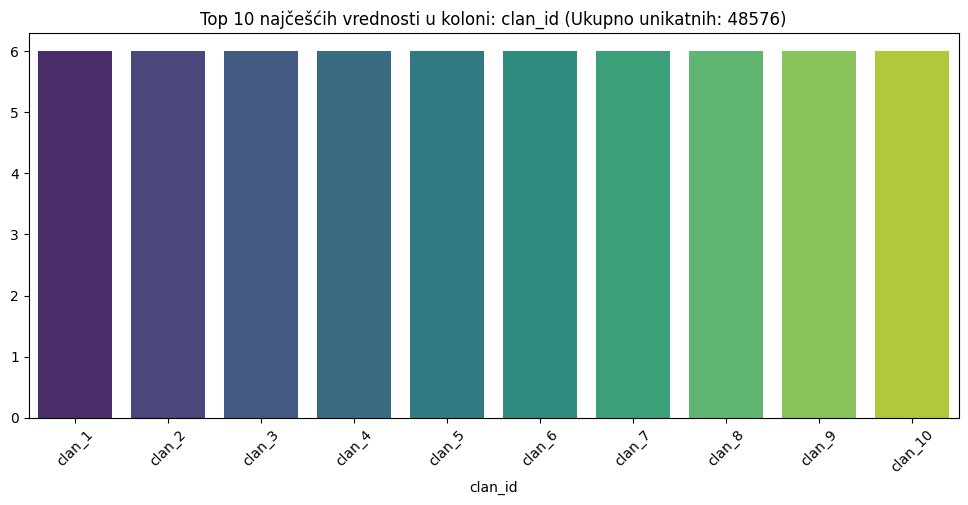

C:\Users\User\AppData\Local\Temp\ipykernel_13328\3110826240.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')


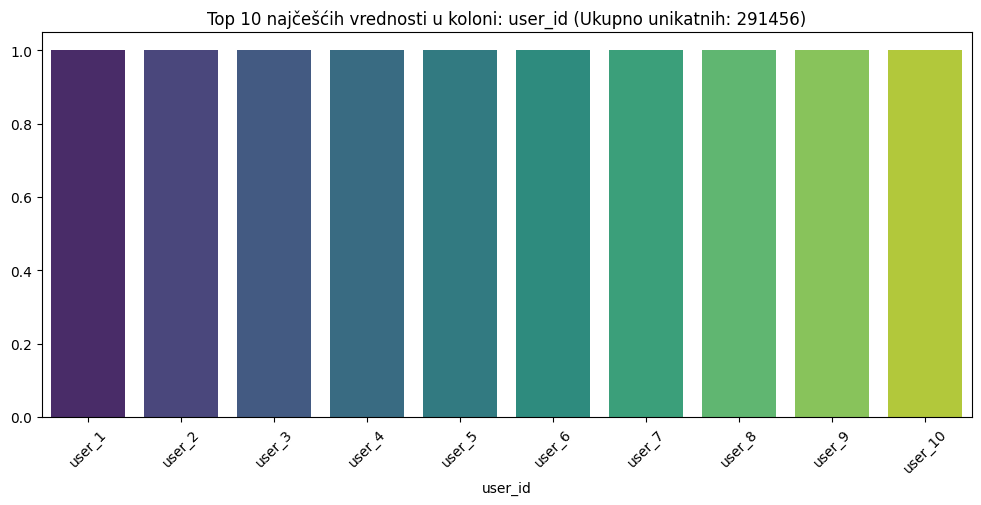

C:\Users\User\AppData\Local\Temp\ipykernel_13328\3110826240.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')


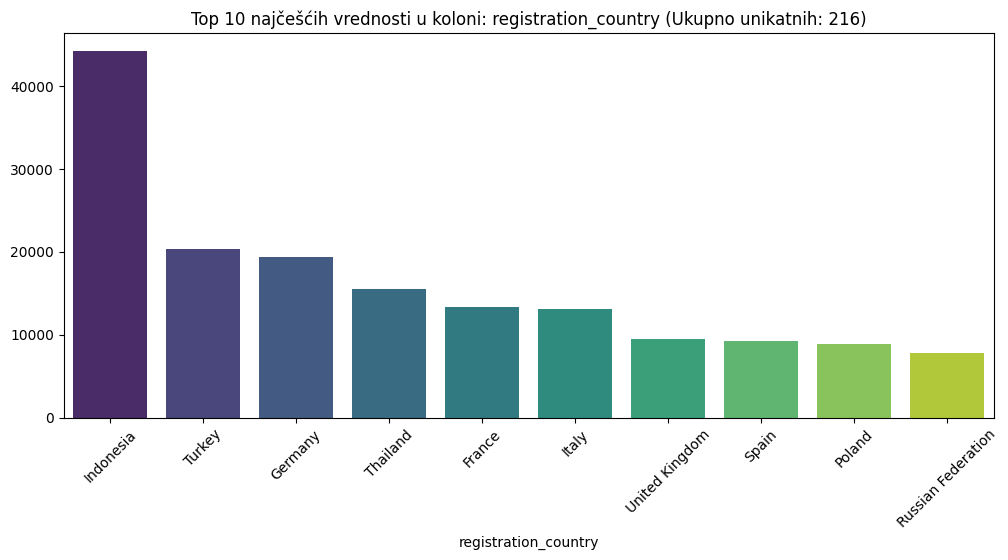

C:\Users\User\AppData\Local\Temp\ipykernel_13328\3110826240.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')


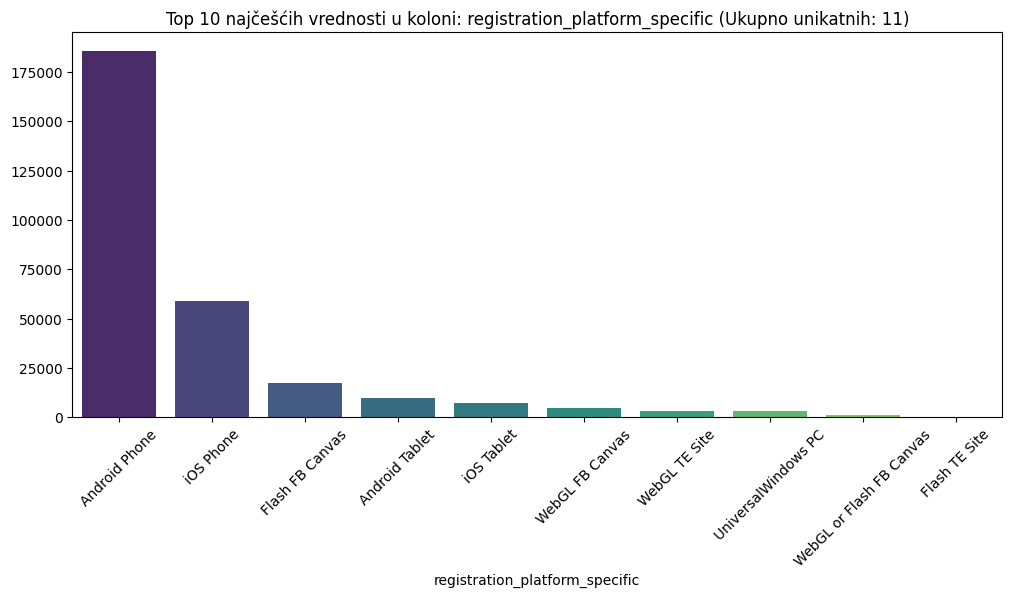

C:\Users\User\AppData\Local\Temp\ipykernel_13328\3110826240.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis', order=df[col].value_counts().index)


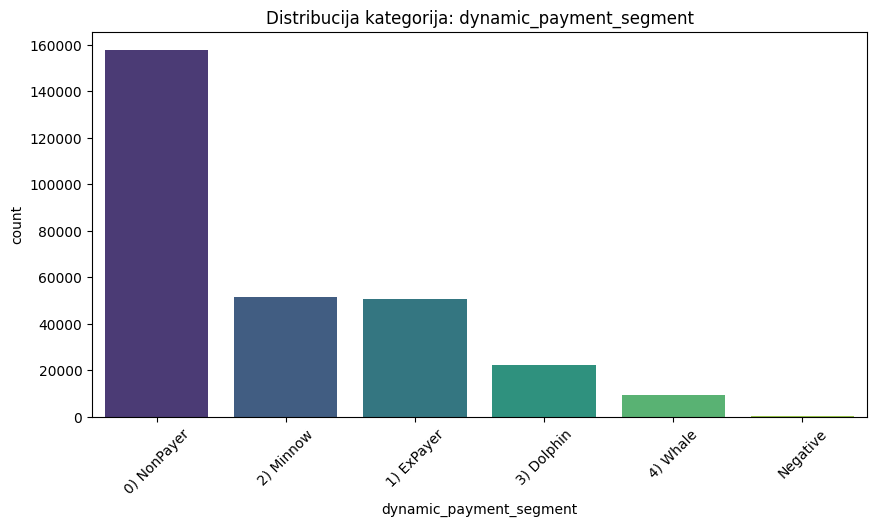

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Uzimamo samo kolone koje su tipa 'object' (stringovi)
string_cols = df.select_dtypes(include=['object']).columns

for col in string_cols:
    n_unique = df[col].nunique()
    
    # Ako kolona ima previše unikatnih vrednosti (kao npr. ID-evi),
    # prikazujemo samo Top 10 najučestalijih da ne zagušimo grafikon
    if n_unique > 10:
        top_values = df[col].value_counts().head(10)
        plt.figure(figsize=(12, 5))
        sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')
        plt.title(f'Top 10 najčešćih vrednosti u koloni: {col} (Ukupno unikatnih: {n_unique})')
    else:
        # Ako ima malo kategorija, crtamo sve
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=col, palette='viridis', order=df[col].value_counts().index)
        plt.title(f'Distribucija kategorija: {col}')

    plt.xticks(rotation=45)
    plt.show()

In [4]:
mapping = {
    '0) NonPayer': 0,
    '1) ExPayer': 1,
    '2) Minnow': 2,
    '3) Dolphin': 3,
    '4) Whale': 4,
    'Negative': -1
}

df['payment_numeric'] = df['dynamic_payment_segment'].map(mapping)

In [5]:
df_matches = pd.read_csv("clan_matches_training.csv")

In [30]:
df_matches.head()

,clan_1_id,clan_2_id,clan_1_points,clan_2_points,clan_winner
0,clan_7201,clan_25726,0,72,2
1,clan_5202,clan_16269,0,78,2
2,clan_26609,clan_2868,0,84,2
3,clan_5093,clan_37398,0,84,2
4,clan_19283,clan_42497,0,90,2


In [93]:
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Skaliranje kolona na opseg [0, 1]
df[['scaled_bonus', 'scaled_stars']] = scaler.fit_transform(df[['avg_training_bonus', 'avg_stars_top_11_players']])


df['power_index'] = (df['avg_training_bonus'] / 10 + df['avg_stars_top_11_players']) 

# 2. Grupišemo članove po klanu i sortiramo ih od 1 do 6
# Svaki klan mora imati tačno 6 članova za simulaciju
df_sorted = df.sort_values(['clan_id', 'power_index'], ascending=[True, False])
df_sorted['rank'] = df_sorted.groupby('clan_id').cumcount() + 1

# Filtriramo samo top 6 (ako neki klan ima više ili manje, ovo ih standardizuje)
df_members = df_sorted[df_sorted['rank'] <= 6].copy()

In [79]:
df_members.head(6)

,clan_id,user_id,days_active_last_28_days,days_active_last_7_days,days_since_last_active,registration_country,registration_platform_specific,cohort_day,training_count_last_28_days,is_payer_lifetime,dynamic_payment_segment,clan_multiplier,avg_stars_top_11_players,avg_stars_top_3_players,avg_training_bonus,payment_numeric,power_index,scaled_bonus,scaled_stars,rank
2690,clan_1,user_2691,28,7,0,Germany,iOS Tablet,1744,607,True,1) ExPayer,3,8.639745,10.084845,15.5,1,72.419236,0.516667,0.516688,1
0,clan_1,user_1,28,7,0,Israel,Android Phone,1721,159,True,4) Whale,3,8.219321,9.440622,15.5,4,71.157963,0.516667,0.492886,2
278791,clan_1,user_278792,28,7,0,Germany,Android Tablet,503,3118,False,0) NonPayer,3,8.441867,9.976933,14.0,0,67.325600,0.466667,0.505485,3
231618,clan_1,user_231619,28,7,0,Germany,Android Tablet,1740,37,True,2) Minnow,3,6.313915,7.193956,12.5,2,56.441745,0.416667,0.385013,4
183840,clan_1,user_183841,28,7,0,Germany,iOS Phone,869,41,True,1) ExPayer,3,6.370861,6.939822,11.5,1,53.612582,0.383333,0.388237,5
158342,clan_1,user_158343,28,7,0,Germany,Android Phone,1777,30,False,0) NonPayer,3,6.794776,7.454311,10.5,0,51.884327,0.350000,0.412237,6


In [94]:
import numpy as np
from tqdm import tqdm

# 1. Prvo sortiramo članove unutar svakog klana po kvalitetu (zvezdicama)
# Pravilo kaže: najbolji igra protiv najboljeg, najgori protiv najgoreg
df_sorted = df_members.sort_values(['clan_id', 'avg_stars_top_11_players'], ascending=[True, False])

# 2. Kreiramo rečnik za brzi pristup podacima
clan_data = {}

# Grupišemo po klanu i izvlačimo tačno 6 članova
for clan_id, group in tqdm(df_sorted.groupby('clan_id'), desc="Populating clan_data"):
    # Uzimamo samo top 6 članova za turnir
    top_6 = group.head(6)
    
    # Proveravamo da li klan ima dovoljno članova za simulaciju
    if len(top_6) == 6:
        clan_data[clan_id] = {
            # 'p' je kvalitet tima (zvezdice)[cite: 1]
            'p': top_6['power_index'].values,
            # 'm' je individualni clan_multiplier[cite: 1]
            'm': top_6['clan_multiplier'].values
        }

Populating clan_data: 100%|██████████| 48576/48576 [00:11<00:00, 4141.89it/s]


In [9]:
from tqdm import tqdm
tqdm.pandas()

In [81]:
import pandas as pd

# Osiguravamo da Pandas ne skraćuje ispis ni po širini ni po visini
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 2000)

# Identifikacija meča (Index 2)
match = df_matches.iloc[2]
c1_id, c2_id = match['clan_1_id'], match['clan_2_id']

# Izvlačenje svih podataka bez filtera kolona
c1_full = df_members[df_members['clan_id'] == c1_id].sort_values('avg_stars_top_11_players', ascending=False)
c2_full = df_members[df_members['clan_id'] == c2_id].sort_values('avg_stars_top_11_players', ascending=False)

print(f"--- SVI PODACI ZA CLAN 1 ({c1_id}) ---")
print(c1_full.to_string())

print("\n" + "="*150 + "\n")

print(f"--- SVI PODACI ZA CLAN 2 ({c2_id}) ---")
print(c2_full.to_string())

--- SVI PODACI ZA CLAN 1 (clan_26609) ---
           clan_id      user_id  days_active_last_28_days  days_active_last_7_days  days_since_last_active registration_country registration_platform_specific  cohort_day  training_count_last_28_days  is_payer_lifetime dynamic_payment_segment  clan_multiplier  avg_stars_top_11_players  avg_stars_top_3_players  avg_training_bonus  payment_numeric  power_index  scaled_bonus  scaled_stars  rank
170551  clan_26609  user_170552                        28                        7                       0               Turkey                      iOS Phone        4595                           91               True                4) Whale                3                  8.683127                 9.591022                11.0                4    59.049381      0.366667      0.519144     1
162964  clan_26609  user_162965                        28                        7                       0               Turkey                      iOS Phone        23

In [95]:
from scipy.optimize import linear_sum_assignment

# --- KORAK 3: VEKTORIZOVANA SIMULACIJA + OPTIMIZACIJA ---
def get_scores_fast(p1, m1, p2, m2):
    # Matrice poena (Clan 1 napada 2, i obrnuto)
    win1 = p1[:, None] > p2
    draw1 = p1[:, None] == p2
    m_c1 = (win1 * 3 + draw1 * 1) * m1[:, None]
    
    win2 = p2[:, None] > p1
    draw2 = p2[:, None] == p1
    m_c2 = (win2 * 3 + draw2 * 1) * m2[:, None]

    # 1. Fair & Tactical (Brze NumPy operacije)
    c1_fair, c2_fair = np.trace(m_c1), np.trace(m_c2)
    c1_tact, c2_tact = np.trace(np.fliplr(m_c1)), np.trace(np.fliplr(m_c2))

    # 2. Best & Worst Case (Mađarski algoritam)
    # Clan 1 najbolje i najgore
    r_b1, c_b1 = linear_sum_assignment(m_c1, maximize=True)
    c1_best = m_c1[r_b1, c_b1].sum()
    r_w1, c_w1 = linear_sum_assignment(m_c1, maximize=False)
    c1_worst = m_c1[r_w1, c_w1].sum()

    # Clan 2 najbolje i najgore
    r_b2, c_b2 = linear_sum_assignment(m_c2, maximize=True)
    c2_best = m_c2[r_b2, c_b2].sum()
    r_w2, c_w2 = linear_sum_assignment(m_c2, maximize=False)
    c2_worst = m_c2[r_w2, c_w2].sum()

    return (c1_fair, c1_tact, c1_best, c1_worst, 
            c2_fair, c2_tact, c2_best, c2_worst)

# --- KORAK 4: IZVRŠAVANJE ---
results = []
for c1_id, c2_id in tqdm(zip(df_matches['clan_1_id'], df_matches['clan_2_id']), 
                         total=len(df_matches), 
                         desc="Simulating all scenarios"):
    d1 = clan_data.get(c1_id)
    d2 = clan_data.get(c2_id)
    
    if d1 is not None and d2 is not None and len(d1['p']) == 6 and len(d2['p']) == 6:
        results.append(get_scores_fast(d1['p'], d1['m'], d2['p'], d2['m']))
    else:
        results.append((0, 0, 0, 0, 0, 0, 0, 0))

# --- KORAK 5: SPAJANJE I NOVI DIFERENCIJALI ---
sim_cols = ['c1_fair', 'c1_tact', 'c1_best', 'c1_worst', 
            'c2_fair', 'c2_tact', 'c2_best', 'c2_worst']

df_sim = pd.DataFrame(results, columns=sim_cols, index=df_matches.index)
df_final = pd.concat([df_matches, df_sim], axis=1)

# Diferencijali za XGBoost
df_final['diff_fair'] = df_final['c1_fair'] - df_final['c2_fair']
df_final['diff_tact'] = df_final['c1_tact'] - df_final['c2_tact']
df_final['diff_best'] = df_final['c1_best'] - df_final['c2_best']
df_final['diff_worst'] = df_final['c1_worst'] - df_final['c2_worst']

# Dodatni feature: Koliki je raspon mogućnosti za Clan 1 (Best - Worst)
df_final['c1_range'] = df_final['c1_best'] - df_final['c1_worst']
df_final['c2_range'] = df_final['c2_best'] - df_final['c2_worst']

Simulating all scenarios: 100%|██████████| 24288/24288 [00:02<00:00, 9498.04it/s] 


In [69]:
# Ako je pobedio klan 1, target je 1. Ako je pobedio klan 2, target je 0.
df_final['target'] = (df_final['clan_winner'] == 1).astype(int)

# Proveri distribuciju da budeš siguran
print(df_final['target'].value_counts())

target
0    12162
1    12126
Name: count, dtype: int64


In [97]:
df_final.head()

,clan_1_id,clan_2_id,clan_1_points,clan_2_points,clan_winner,c1_fair,c1_tact,c1_best,c1_worst,c2_fair,c2_tact,c2_best,c2_worst,diff_fair,diff_tact,diff_best,diff_worst,c1_range,c2_range,target
0,clan_7201,clan_25726,0,72,2,27,36,42,12,18,18,36,9,9,18,6,3,30,27,0
1,clan_5202,clan_16269,0,78,2,3,24,36,0,42,27,42,9,-39,-3,-6,-9,36,33,0
2,clan_26609,clan_2868,0,84,2,33,27,36,18,18,18,33,12,15,9,3,6,18,21,0
3,clan_5093,clan_37398,0,84,2,9,15,15,9,42,33,42,30,-33,-18,-27,-21,6,12,0
4,clan_19283,clan_42497,0,90,2,0,6,9,0,51,42,51,33,-51,-36,-42,-33,9,18,0


In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# --- KORAK 1: AUGMENTACIJA ZA SIMETRIJU ---
# Pravimo duplikat gde Clan 1 i Clan 2 menjaju mesta
df_copy = df_final.copy()

# Menjamo predznake diferencijalima (ako C1-C2 postane C2-C1, znak se menja)
for col in features:
    df_copy[col] = -df_copy[col]

# Menjamo target (ako je pobedio 1, u ogledalu je pobedio 2, tj. target postaje 0)
df_copy['target'] = 1 - df_copy['target']

# Spajamo original i ogledalo
df_symmetric = pd.concat([df_final, df_copy], axis=0).reset_index(drop=True)

In [103]:
# --- KORAK 2: MODELOVANJE ---
X = df_symmetric[features]
y = df_symmetric['target']

# Skaliranje je obavezno za LogReg
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Podela na train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Inicijalizacija i trening
# Koristimo liblinear jer je dobar za manje setove podataka
model_logreg = LogisticRegression(solver='liblinear', C=1.0) 
model_logreg.fit(X_train, y_train)

# Predikcija
y_pred = model_logreg.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.5649
